# 1. Polynomial Regression için gerekli kütüphane

In [27]:
# Veri yükleme
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

df = pd.read_csv("trainDataSet.csv", sep=';')

# Kolon isimlerinden tırnak ve baş/son boşlukları temizle
df.columns = df.columns.str.replace('"','').str.strip()

# Kontrol et
print(df.columns)

Index(['Month', 'DayOfWeek', 'FlightDate', 'Operating_Airline',
       'Flight_Number_Operating_Airline', 'OriginAirportID', 'Origin',
       'OriginCityName', 'DestAirportID', 'Dest', 'DestCityName', 'CRSDepTime',
       'DepTime', 'DepDelayMinutes', 'DepDel15', 'CRSArrTime', 'ArrTime',
       'ArrDelayMinutes', 'ArrDel15', 'Cancelled', 'CancellationCode',
       'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime',
       'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay',
       'LateAircraftDelay'],
      dtype='str')


# 2. Feature ve Target seçimi

In [28]:
# Feature ve Target

X = df[['WeatherDelay']]
y = df['ArrDelayMinutes']

# 3. Veriyi temizleme

In [29]:
X = pd.to_numeric(X['WeatherDelay'], errors='coerce')
y = pd.to_numeric(y, errors='coerce')

data = pd.concat([X, y], axis=1).dropna()

X = data[['WeatherDelay']]
y = data['ArrDelayMinutes']

# 4. Polynomial Feature oluşturma

In [30]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

# 5. Model oluşturma ve eğitme

In [31]:
model = LinearRegression()

model.fit(X_poly, y)

print("Polynomial model eğitildi")

Polynomial model eğitildi


# 6. Tahmin yapma

In [32]:
y_pred = model.predict(X_poly)

# 7. Polynomial eğriyi görselleştirme

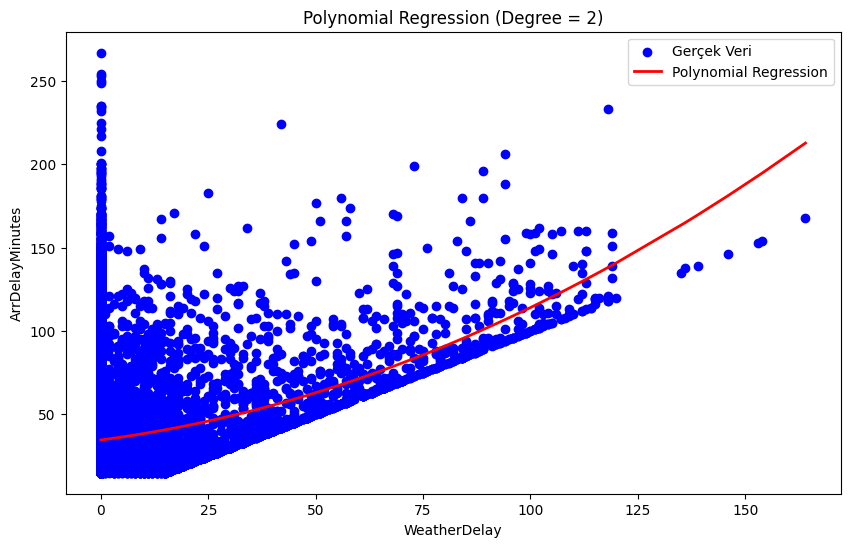

In [33]:
plt.figure(figsize=(10,6))

plt.scatter(X, y, color='blue', label='Gerçek Veri')

# düzgün eğri çizmek için sıralama
sorted_index = X['WeatherDelay'].argsort()

plt.plot(X.iloc[sorted_index],
         y_pred[sorted_index],
         color='red',
         linewidth=2,
         label='Polynomial Regression')

plt.xlabel("WeatherDelay")
plt.ylabel("ArrDelayMinutes")

plt.title("Polynomial Regression (Degree = 2)")

plt.legend()

plt.show()